In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests


In [2]:
!pip install requests pandas matplotlib


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
print("""
Threat Intelligence Agent

Goal:
Build an AI-based vulnerability prioritization system using:

1. NVD (National Vulnerability Database)
2. KEV (Known Exploited Vulnerabilities)
3. EPSS (Exploit Prediction Scoring System)
4. MITRE ATT&CK

Purpose:
To help organizations prioritize vulnerabilities based on:
- Severity
- Active exploitation
- Exploit probability
- Attack behavior
""")


Threat Intelligence Agent

Goal:
Build an AI-based vulnerability prioritization system using:

1. NVD (National Vulnerability Database)
2. KEV (Known Exploited Vulnerabilities)
3. EPSS (Exploit Prediction Scoring System)
4. MITRE ATT&CK

Purpose:
To help organizations prioritize vulnerabilities based on:
- Severity
- Active exploitation
- Exploit probability
- Attack behavior



In [4]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

url = "https://services.nvd.nist.gov/rest/json/cves/2.0?resultsPerPage=500"

response = requests.get(url)

print("Status:", response.status_code)

data = response.json()

Status: 200


In [5]:
records = []

for item in data["vulnerabilities"]:
    cve = item["cve"]

    cve_id = cve["id"]
    published = cve["published"]

    cvss_score = None
    if "metrics" in cve:
        if "cvssMetricV31" in cve["metrics"]:
            cvss_score = cve["metrics"]["cvssMetricV31"][0]["cvssData"]["baseScore"]

    cwe = None
    if "weaknesses" in cve:
        try:
            cwe = cve["weaknesses"][0]["description"][0]["value"]
        except:
            cwe = None

    records.append({
        "id": cve_id,
        "published": published,
        "cvss_score": cvss_score,
        "cwe": cwe
    })

df = pd.DataFrame(records)

In [6]:
df["published"] = pd.to_datetime(df["published"])
df["year"] = df["published"].dt.year

In [7]:
df = df[df["year"] >= 2020]

In [8]:
records = []

for item in data["vulnerabilities"]:
    cve = item["cve"]

    cve_id = cve["id"]
    published = cve["published"]
    vuln_status = cve.get("vulnStatus", None)

    description = cve["descriptions"][0]["value"]

    cwe = None
    if "weaknesses" in cve:
        try:
            cwe = cve["weaknesses"][0]["description"][0]["value"]
        except:
            cwe = None

    cvss_score = None
    if "metrics" in cve:
        if "cvssMetricV31" in cve["metrics"]:
            cvss_score = cve["metrics"]["cvssMetricV31"][0]["cvssData"]["baseScore"]

    records.append({
        "id": cve_id,
        "published": published,
        "status": vuln_status,
        "description": description,
        "cwe": cwe,
        "cvss_score": cvss_score
    })

df = pd.DataFrame(records)

df.head()

,id,published,status,description,cwe,cvss_score
0,CVE-1999-0095,1988-10-01T04:00:00.000,Modified,"The debug command in Sendmail is enabled, allo...",NVD-CWE-Other,NaN
1,CVE-1999-0082,1988-11-11T05:00:00.000,Modified,CWD ~root command in ftpd allows root access.,NVD-CWE-Other,NaN
2,CVE-1999-1471,1989-01-01T05:00:00.000,Modified,Buffer overflow in passwd in BSD based operati...,NVD-CWE-Other,NaN
3,CVE-1999-1122,1989-07-26T04:00:00.000,Modified,Vulnerability in restore in SunOS 4.0.3 and ea...,NVD-CWE-Other,NaN
4,CVE-1999-1467,1989-10-26T04:00:00.000,Modified,Vulnerability in rcp on SunOS 4.0.x allows rem...,NVD-CWE-Other,NaN


In [9]:
print(df.shape)
print(df.isnull().sum())

(500, 6)
id               0
published        0
status           0
description      0
cwe              4
cvss_score     482
dtype: int64


In [10]:
df["published"] = pd.to_datetime(df["published"])
df["year"] = df["published"].dt.year

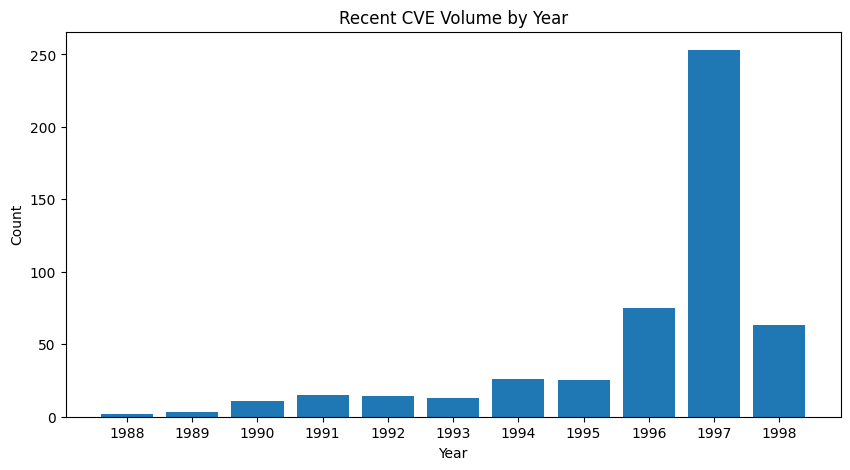

In [11]:
yearly = df.groupby("year").size()

plt.figure(figsize=(10,5))
plt.bar(yearly.index.astype(str), yearly.values)
plt.title("Recent CVE Volume by Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

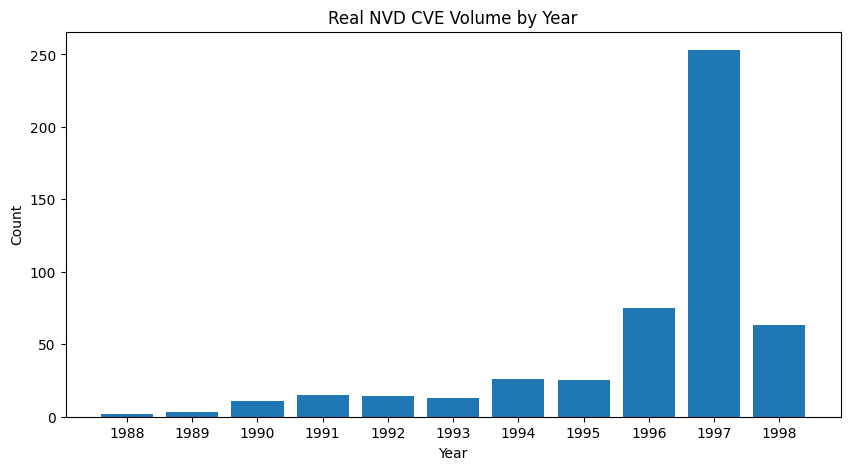

In [12]:
yearly = df.groupby("year").size()

plt.figure(figsize=(10,5))
plt.bar(yearly.index.astype(str), yearly.values)
plt.title("Real NVD CVE Volume by Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

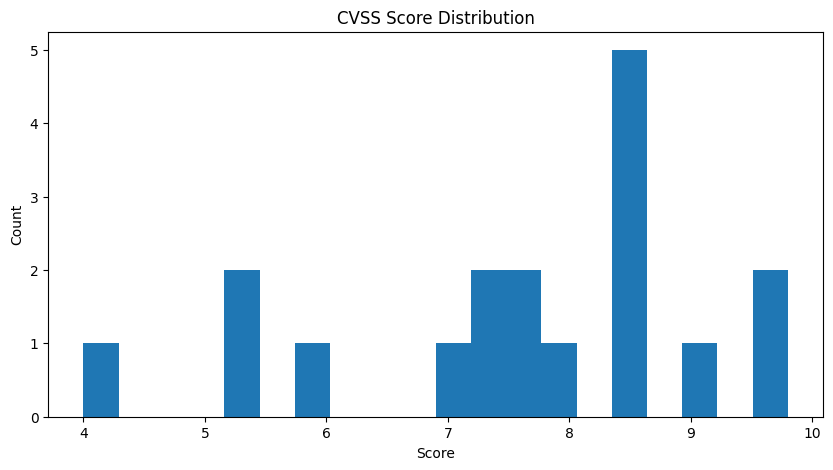

In [13]:
plt.figure(figsize=(10,5))
plt.hist(df["cvss_score"].dropna(), bins=20)
plt.title("CVSS Score Distribution")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

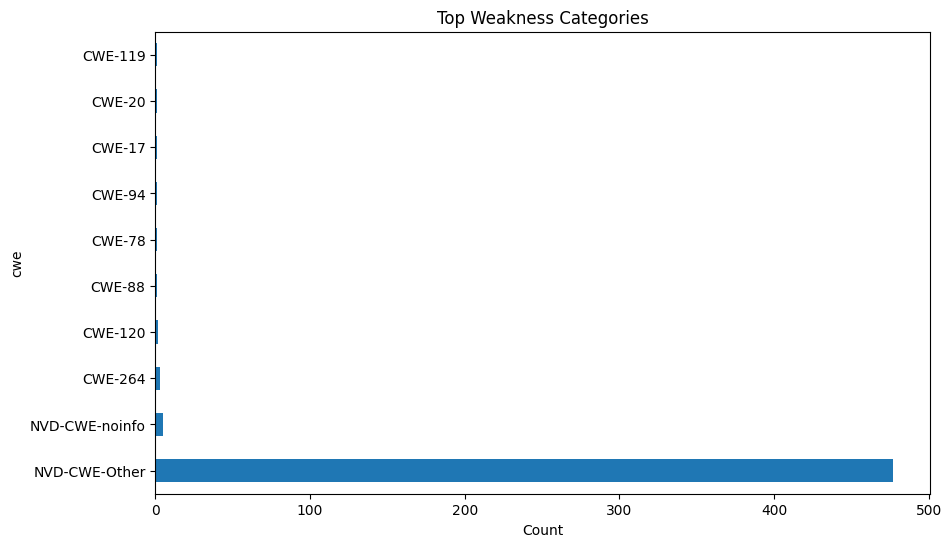

In [14]:
top_cwe = df["cwe"].value_counts().head(10)

plt.figure(figsize=(10,6))
top_cwe.plot(kind="barh")
plt.title("Top Weakness Categories")
plt.xlabel("Count")
plt.show()